# Kapitulli III/V  Analiza Forenzike (ELA, CFA, DCT)

Ky notebook përdor modulet ekzistuese `src/forensic_layer/` (ela.py,
cfa.py, dct.py, visualization.py) për të vizualizuar dhe krahasuar
sinjalet forenzike mbi mostra real/fake. NUK zëvendëson ato module,
vetëm i thërret dhe i interpreton rezultatet.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.forensic_layer.ela import compute_ela_map, compute_ela_score
from src.forensic_layer.cfa import compute_cfa_score
from src.forensic_layer.dct import compute_dct_score
from src.forensic_layer.visualization import (
    normalize_heatmap, apply_colormap, create_overlay,
    compute_cfa_visualization, compute_dct_block_visualization,
)

FRAMES_DIR = PROJECT_ROOT / "data" / "frames"
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Rezultatet e Testit Batch (të dokumentuara tashmë)

Përmbledhje e gjetjeve nga testet statistikore batch (50 real + 50 fake secili), jo rillogaritje, thjesht referencë për interpretim.

In [2]:
batch_summary = {
    "ELA": {"real_mean": 0.0207, "fake_mean": 0.0196, "separation": "asnjë (ranges fully overlapping)"},
    "CFA": {"real_mean": 0.2901, "fake_mean": 0.3326, "separation": "moderate (+0.0425, drejtim i pritur)"},
    "DCT (log-transformed median)": {"real_median": 0.0081, "fake_median": 0.0025, "separation": "e fortë (~3.2x, por polariteti u fiksua)"},
}

for signal, stats in batch_summary.items():
    print(f"{signal}: {stats}")

ELA: {'real_mean': 0.0207, 'fake_mean': 0.0196, 'separation': 'asnjë (ranges fully overlapping)'}
CFA: {'real_mean': 0.2901, 'fake_mean': 0.3326, 'separation': 'moderate (+0.0425, drejtim i pritur)'}
DCT (log-transformed median): {'real_median': 0.0081, 'fake_median': 0.0025, 'separation': 'e fortë (~3.2x, por polariteti u fiksua)'}


## 2. ELA - Error Level Analysis (mostra vizuale)

Pipeline: `compute_ela_map()` (hartë e papërpunuar) → `normalize_heatmap()` → `apply_colormap()` → opsionale `create_overlay()` mbi imazhin origjinal.

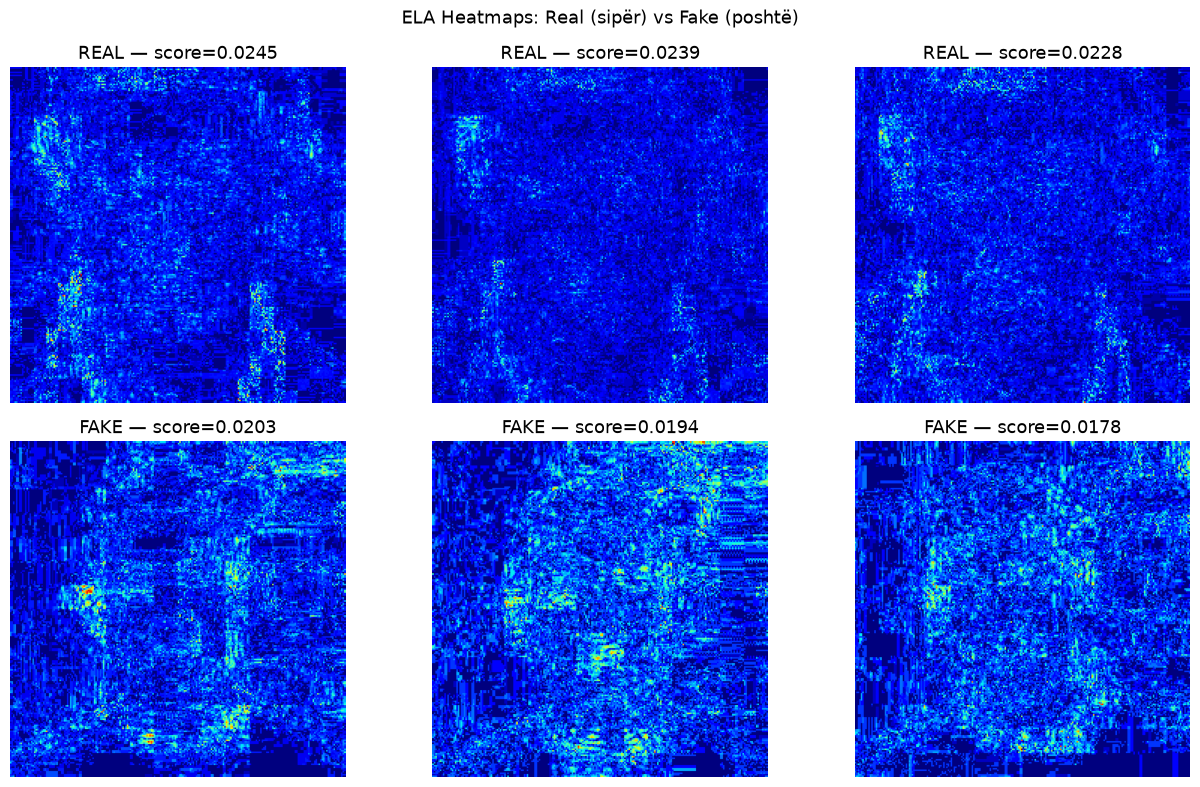

Vërejtje: ELA s'tregon ndarje të qartë real/fake në këtë dataset
shih gjetjen e dokumentuar (JPEG quality=95 uniforme gjatë ekstraktimit).


In [3]:
real_samples = list((FRAMES_DIR / "test" / "real").glob("*.jpg"))[:3]
fake_samples = list((FRAMES_DIR / "test" / "fake").glob("*.jpg"))[:3]

def ela_heatmap_rgb(image_path: str) -> np.ndarray:
    raw_map = compute_ela_map(image_path)
    normalized = normalize_heatmap(raw_map)
    return apply_colormap(normalized, colormap="jet")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for i, img_path in enumerate(real_samples):
    heatmap_rgb = ela_heatmap_rgb(str(img_path))
    score = compute_ela_score(str(img_path))
    axes[0, i].imshow(heatmap_rgb)
    axes[0, i].set_title(f"REAL — score={score:.4f}")
    axes[0, i].axis("off")

for i, img_path in enumerate(fake_samples):
    heatmap_rgb = ela_heatmap_rgb(str(img_path))
    score = compute_ela_score(str(img_path))
    axes[1, i].imshow(heatmap_rgb)
    axes[1, i].set_title(f"FAKE — score={score:.4f}")
    axes[1, i].axis("off")

plt.suptitle("ELA Heatmaps: Real (sipër) vs Fake (poshtë)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "ela_sample_comparison.png", dpi=150)
plt.show()

print("Vërejtje: ELA s'tregon ndarje të qartë real/fake në këtë dataset")
print("shih gjetjen e dokumentuar (JPEG quality=95 uniforme gjatë ekstraktimit).")

## 2b. ELA — Overlay mbi Imazhin Origjinal (shembull i vetëm)

`create_overlay()` kombinon heatmap-in me imazhin origjinal...format i dobishëm për raportin e paraqitjes në gjykatë.

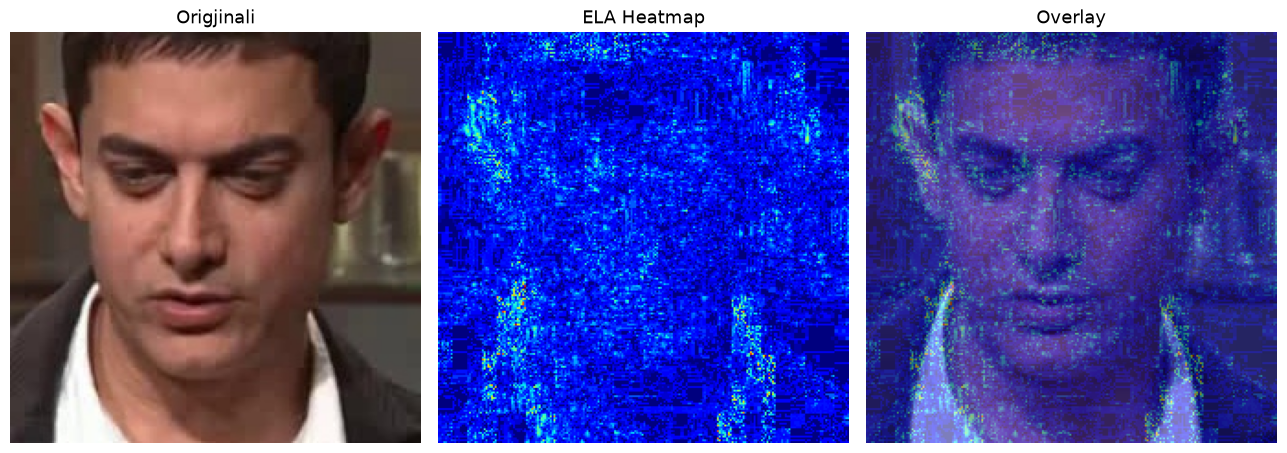

In [4]:
sample_path = real_samples[0]
original_img = Image.open(sample_path).convert("RGB")
heatmap_rgb = ela_heatmap_rgb(str(sample_path))
overlay_img = create_overlay(original_img, heatmap_rgb, alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].imshow(original_img); axes[0].set_title("Origjinali"); axes[0].axis("off")
axes[1].imshow(heatmap_rgb); axes[1].set_title("ELA Heatmap"); axes[1].axis("off")
axes[2].imshow(overlay_img); axes[2].set_title("Overlay"); axes[2].axis("off")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "ela_overlay_example.png", dpi=150)
plt.show()

## 3. CFA — Color Filter Array (mostra vizuale)

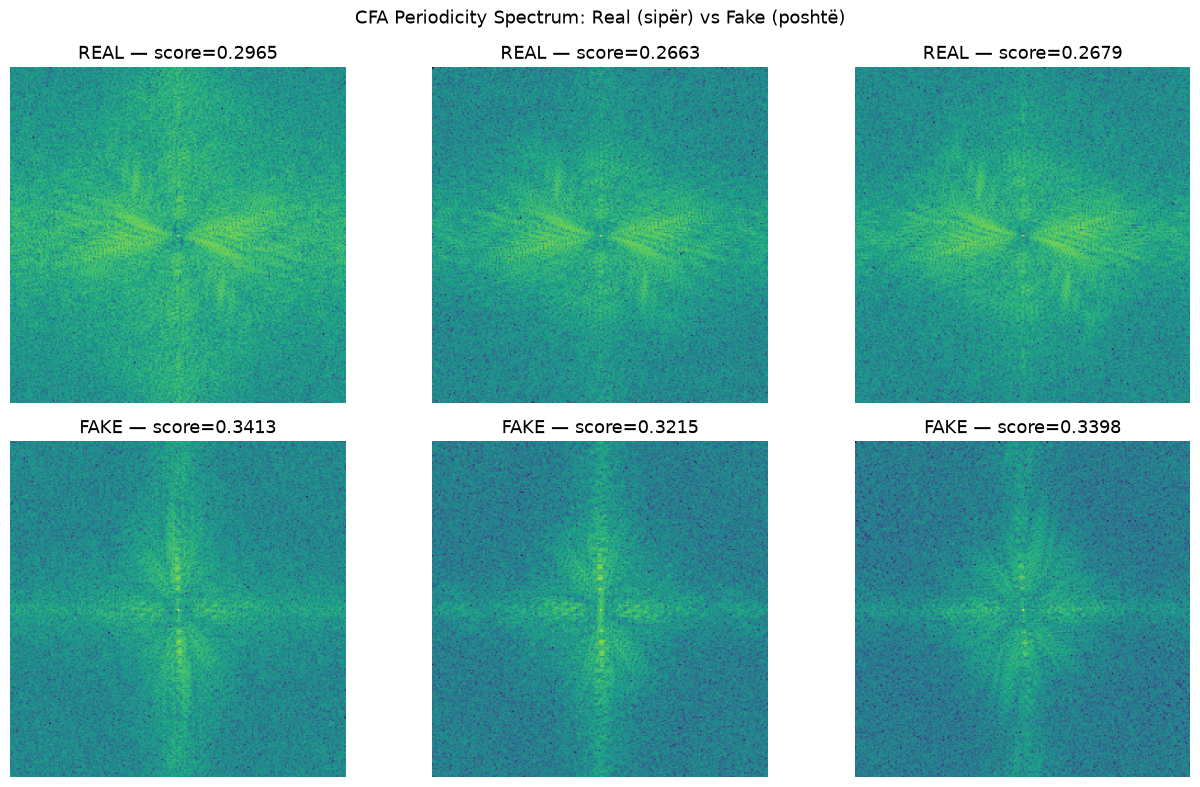

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for i, img_path in enumerate(real_samples):
    spectrum = compute_cfa_visualization(str(img_path))
    score = compute_cfa_score(str(img_path))
    axes[0, i].imshow(spectrum, cmap="viridis")
    axes[0, i].set_title(f"REAL — score={score:.4f}")
    axes[0, i].axis("off")

for i, img_path in enumerate(fake_samples):
    spectrum = compute_cfa_visualization(str(img_path))
    score = compute_cfa_score(str(img_path))
    axes[1, i].imshow(spectrum, cmap="viridis")
    axes[1, i].set_title(f"FAKE — score={score:.4f}")
    axes[1, i].axis("off")

plt.suptitle("CFA Periodicity Spectrum: Real (sipër) vs Fake (poshtë)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "cfa_sample_comparison.png", dpi=150)
plt.show()

## 4. DCT: 8x8 Block Energy Map (mostra vizuale)

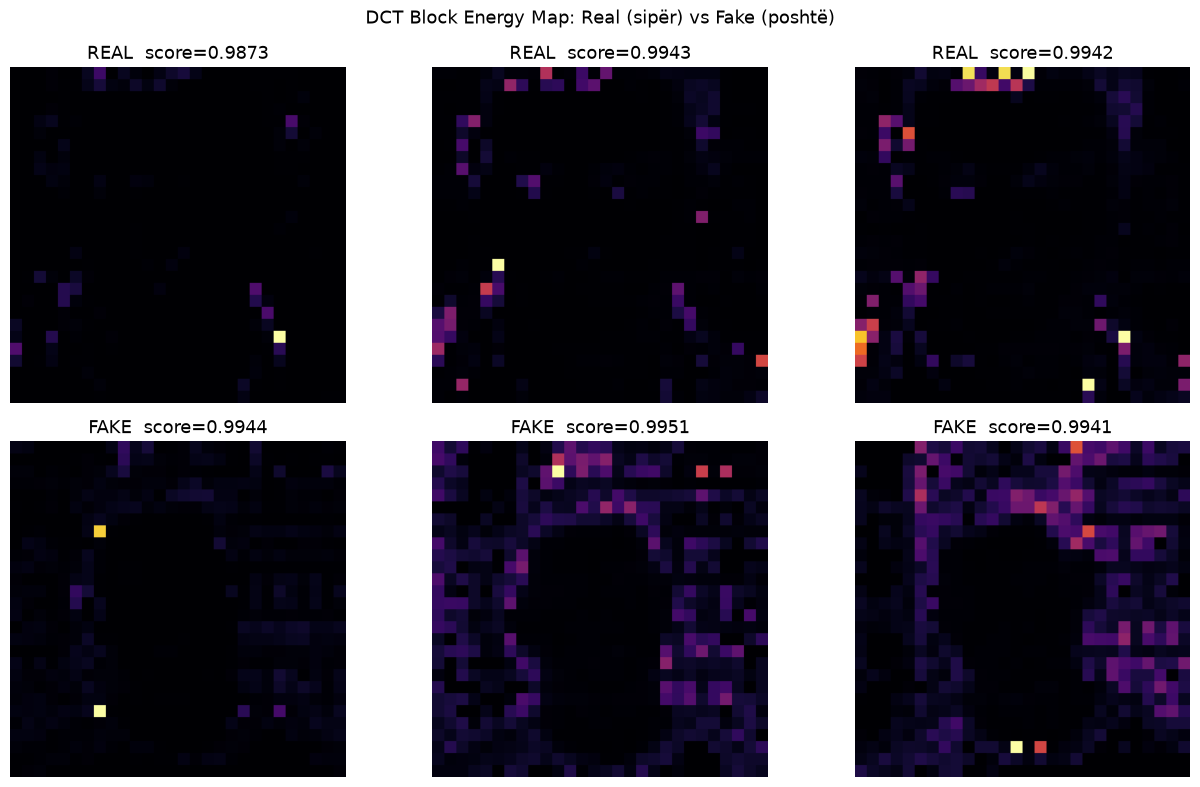

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for i, img_path in enumerate(real_samples):
    energy_map = compute_dct_block_visualization(str(img_path))
    score = compute_dct_score(str(img_path))
    axes[0, i].imshow(energy_map, cmap="inferno")
    axes[0, i].set_title(f"REAL  score={score:.4f}")
    axes[0, i].axis("off")

for i, img_path in enumerate(fake_samples):
    energy_map = compute_dct_block_visualization(str(img_path))
    score = compute_dct_score(str(img_path))
    axes[1, i].imshow(energy_map, cmap="inferno")
    axes[1, i].set_title(f"FAKE  score={score:.4f}")
    axes[1, i].axis("off")

plt.suptitle("DCT Block Energy Map: Real (sipër) vs Fake (poshtë)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "dct_sample_comparison.png", dpi=150)
plt.show()

## 5. Konkluzion i Shkurtër

ELA nuk ofron sinjal të dobishëm në këtë dataset (shkak: kompresim JPEG uniform gjatë ekstraktimit). CFA ofron sinjal të moderuar. DCT ofron sinjal të fortë, por me polaritet të kundërt nga pritshmëria fillestare (fake ka MË PAK energji të lartë-frekuencë, jo më shumë. Shpjegohet nga 'over-smoothing' i GAN-eve).